# RQ1.ipynb

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [6]:

df = pd.read_csv(r'C:\Users\vrund\Downloads\ML\amazon_sales_2025_INR.csv')
df = df.select_dtypes(include=[np.number]).dropna()
target = df.columns[-1]
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


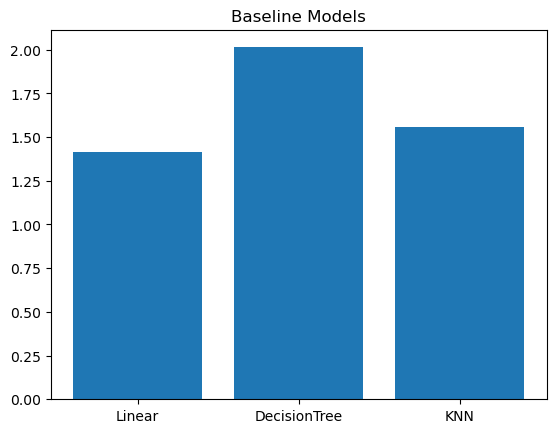

In [7]:

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append([name, mae, rmse, r2])

df_res = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"])
df_res.to_csv("RQ1_table.csv", index=False)

plt.figure()
plt.bar(df_res["Model"], df_res["RMSE"])
plt.title("Baseline Models")
plt.savefig("RQ1_figure.pdf")
